<a href="https://colab.research.google.com/github/navap3206-debug/hello-world/blob/main/A01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Para los datos de los archivos "bateria_tableta.txt" y "Salarios_minimos.csv":**

- Realiza regresiones polinomiales de orden 1, 3, 5 y 7.

- Compara el R2 que te da cada modelo.

- Crea una gráfica con una nube de dispersión (datos originales) y tus modelos.




In [140]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from google.colab import files
import matplotlib.pyplot as plt

# ***PREPARACIÓN DE LOS DATOS***

In [173]:
df = files.upload()

Saving Salarios_minimos.csv to Salarios_minimos (2).csv
Saving bateria_tableta.txt to bateria_tableta (2).txt


In [204]:
#Abrimos los archivos
salarios = pd.read_csv('Salarios_minimos.csv')
tableta = pd.read_csv('bateria_tableta.txt')

In [205]:
salarios.head(10) #identificamos el numero de variables en este caso Y y X donde la variable de control es el Periodo

,Periodo,Salario
0,1988.25,8.00
1,1989.00,8.64
2,1989.50,9.16
3,1990.00,10.08
4,1990.84,11.90
5,1991.84,13.33
6,1993.00,14.27
7,1994.00,15.27
8,1995.00,16.34
9,1995.30,18.30


In [206]:
tableta.head(10) #La variable de control es la carga

,carga,duracion
0,2.81,5.62
1,7.14,8.00
2,2.72,5.44
3,3.87,7.74
4,1.90,3.80
5,7.82,8.00
6,7.02,8.00
7,5.50,8.00
8,9.15,8.00
9,4.87,8.00


In [288]:
matriz_sl = salarios.to_numpy() #Transformamos en matriz manipulable con numpy
matriz_tb = tableta.to_numpy()

In [289]:
print(matriz_sl , matriz_tb, sep='\n \n') #Comprobamos su orden, en caso de carga debemos ordenar

[[1988.25    8.  ]
 [1989.      8.64]
 [1989.5     9.16]
 [1990.     10.08]
 [1990.84   11.9 ]
 [1991.84   13.33]
 [1993.     14.27]
 [1994.     15.27]
 [1995.     16.34]
 [1995.3    18.3 ]
 [1996.     20.15]
 [1996.3    22.6 ]
 [1997.     26.45]
 [1998.     30.2 ]
 [1999.     34.45]
 [2000.     37.9 ]
 [2001.     40.35]
 [2002.     42.15]
 [2003.     43.65]
 [2004.     45.24]
 [2005.     46.8 ]
 [2006.     48.67]
 [2007.     50.57]
 [2008.     52.59]
 [2009.     54.8 ]
 [2010.     57.46]
 [2011.     59.82]
 [2012.     62.33]
 [2013.     64.76]
 [2014.     67.29]
 [2015.     70.1 ]
 [2016.     73.04]
 [2017.     80.04]
 [2018.     88.36]]
 
[[ 2.81  5.62]
 [ 7.14  8.  ]
 [ 2.72  5.44]
 [ 3.87  7.74]
 [ 1.9   3.8 ]
 [ 7.82  8.  ]
 [ 7.02  8.  ]
 [ 5.5   8.  ]
 [ 9.15  8.  ]
 [ 4.87  8.  ]
 [ 8.08  8.  ]
 [ 5.58  8.  ]
 [ 9.13  8.  ]
 [ 0.14  0.28]
 [ 2.    4.  ]
 [ 5.47  8.  ]
 [ 0.8   1.6 ]
 [ 4.37  8.  ]
 [ 5.31  8.  ]
 [ 0.    0.  ]
 [ 1.78  3.56]
 [ 3.45  6.9 ]
 [ 6.13  8.  ]
 [ 3.5

**REGRESIÓN PARA SALARIOS MINIMOS Y DURACIÓN DE CARGA**

Elección de datos de prueba...




In [290]:
print("1) Salarios")
print("2) Duración de carga")
ans = int(input("Datos de ajuste..."))


if ans == 1:
  matriz_ = matriz_sl
  print("Datos de salarios")

elif ans == 2:
  matriz_ = matriz_tb
  print("Datos de carga")
else:
  print("Error")

1) Salarios
2) Duración de carga
Datos de ajuste...1
Datos de salarios


COmo se menciono, será necesario reordenar el vector Y...

In [291]:
# matriz[:, 0] selecciona todos los elementos de la primera columna
indices = np.argsort(matriz_[:, 0])

# 2. Aplicamos esos índices a toda la matriz para reordenar las filas
matriz_ = matriz_[indices]
#comprobamos
matriz_


array([[1988.25,    8.  ],
       [1989.  ,    8.64],
       [1989.5 ,    9.16],
       [1990.  ,   10.08],
       [1990.84,   11.9 ],
       [1991.84,   13.33],
       [1993.  ,   14.27],
       [1994.  ,   15.27],
       [1995.  ,   16.34],
       [1995.3 ,   18.3 ],
       [1996.  ,   20.15],
       [1996.3 ,   22.6 ],
       [1997.  ,   26.45],
       [1998.  ,   30.2 ],
       [1999.  ,   34.45],
       [2000.  ,   37.9 ],
       [2001.  ,   40.35],
       [2002.  ,   42.15],
       [2003.  ,   43.65],
       [2004.  ,   45.24],
       [2005.  ,   46.8 ],
       [2006.  ,   48.67],
       [2007.  ,   50.57],
       [2008.  ,   52.59],
       [2009.  ,   54.8 ],
       [2010.  ,   57.46],
       [2011.  ,   59.82],
       [2012.  ,   62.33],
       [2013.  ,   64.76],
       [2014.  ,   67.29],
       [2015.  ,   70.1 ],
       [2016.  ,   73.04],
       [2017.  ,   80.04],
       [2018.  ,   88.36]])

In [292]:
#DIVIDIMOS LAS MATRICES EN X Y Y
xsl_matrix = np.array([[sl[0]] for sl in matriz_])
y_vec = np.array([[sl[1]] for sl in matriz_])
print(xsl_matrix)
print(y_vec)


[[1988.25]
 [1989.  ]
 [1989.5 ]
 [1990.  ]
 [1990.84]
 [1991.84]
 [1993.  ]
 [1994.  ]
 [1995.  ]
 [1995.3 ]
 [1996.  ]
 [1996.3 ]
 [1997.  ]
 [1998.  ]
 [1999.  ]
 [2000.  ]
 [2001.  ]
 [2002.  ]
 [2003.  ]
 [2004.  ]
 [2005.  ]
 [2006.  ]
 [2007.  ]
 [2008.  ]
 [2009.  ]
 [2010.  ]
 [2011.  ]
 [2012.  ]
 [2013.  ]
 [2014.  ]
 [2015.  ]
 [2016.  ]
 [2017.  ]
 [2018.  ]]
[[ 8.  ]
 [ 8.64]
 [ 9.16]
 [10.08]
 [11.9 ]
 [13.33]
 [14.27]
 [15.27]
 [16.34]
 [18.3 ]
 [20.15]
 [22.6 ]
 [26.45]
 [30.2 ]
 [34.45]
 [37.9 ]
 [40.35]
 [42.15]
 [43.65]
 [45.24]
 [46.8 ]
 [48.67]
 [50.57]
 [52.59]
 [54.8 ]
 [57.46]
 [59.82]
 [62.33]
 [64.76]
 [67.29]
 [70.1 ]
 [73.04]
 [80.04]
 [88.36]]


*GRADO 1*

Procedimiento general:


*   Ajustamos la regresión
*   Identificamos el intercepto
*   Buscamos el error mediante R2
*   Identificamos los coeficientes de las variables libres
*   COnformamos la ecuación de la recta e imprimimos en la grafica



In [293]:
lr = LinearRegression(fit_intercept= True) #no consideramos los interceptos
lr.fit(xsl_matrix, y_vec) #Entrenamos la regresión
inter = lr.intercept_  #Intercepto
inter

array([-5022.60217164])

In [294]:
lr.score(xsl_matrix, y_vec)

0.98445666630952

In [295]:
var = lr.coef_ #variables libres ajustadas
var

array([[2.52832885]])

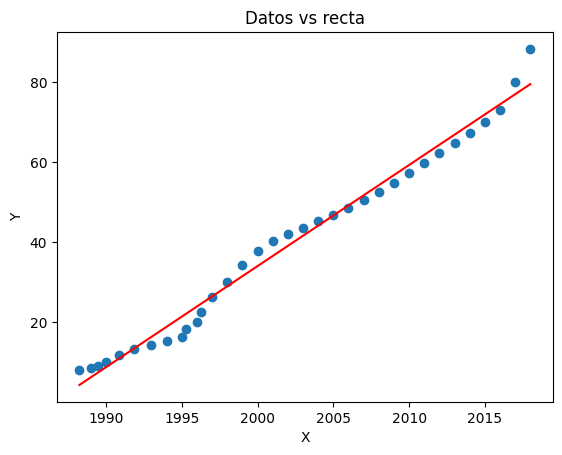

In [296]:
x = xsl_matrix
y = y_vec

y_recta = inter + var * x

plt.scatter(x, y)
plt.plot(x, y_recta, color='red')

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Datos vs recta")

plt.show()

*GRADO 3*

In [301]:
#Creo arrays de X / Y, además de agregar variable libre de grado 2
x3sl_matrix = np.array([[sl[0], sl[0]**2, sl[0]**3] for sl in matriz_])
y_vec = np.array([[sl[1]] for sl in matriz_])
x3sl_matrix

array([[1.98825000e+03, 3.95313806e+06, 7.85982675e+09],
       [1.98900000e+03, 3.95612100e+06, 7.86872467e+09],
       [1.98950000e+03, 3.95811025e+06, 7.87466034e+09],
       [1.99000000e+03, 3.96010000e+06, 7.88059900e+09],
       [1.99084000e+03, 3.96344391e+06, 7.89058267e+09],
       [1.99184000e+03, 3.96742659e+06, 7.90247897e+09],
       [1.99300000e+03, 3.97204900e+06, 7.91629366e+09],
       [1.99400000e+03, 3.97603600e+06, 7.92821578e+09],
       [1.99500000e+03, 3.98002500e+06, 7.94014988e+09],
       [1.99530000e+03, 3.98122209e+06, 7.94373244e+09],
       [1.99600000e+03, 3.98401600e+06, 7.95209594e+09],
       [1.99630000e+03, 3.98521369e+06, 7.95568209e+09],
       [1.99700000e+03, 3.98800900e+06, 7.96405397e+09],
       [1.99800000e+03, 3.99200400e+06, 7.97602399e+09],
       [1.99900000e+03, 3.99600100e+06, 7.98800600e+09],
       [2.00000000e+03, 4.00000000e+06, 8.00000000e+09],
       [2.00100000e+03, 4.00400100e+06, 8.01200600e+09],
       [2.00200000e+03, 4.00800

In [302]:
lr = LinearRegression(fit_intercept= True) #no consideramos los interceptos en nuestra matriz
lr.fit(x3sl_matrix, y_vec) #Entrenamos la regresión
inter_3 = lr.intercept_  #Intercepto
inter_3

array([-5217722.95826932])

In [303]:
lr.score(x3sl_matrix, y_vec) #R2

0.9857366949646496

In [304]:
var_3 = lr.coef_ #variables libres ajustadas
var_3

array([[ 7.83146244e+03, -3.91934110e+00,  6.54024500e-04]])

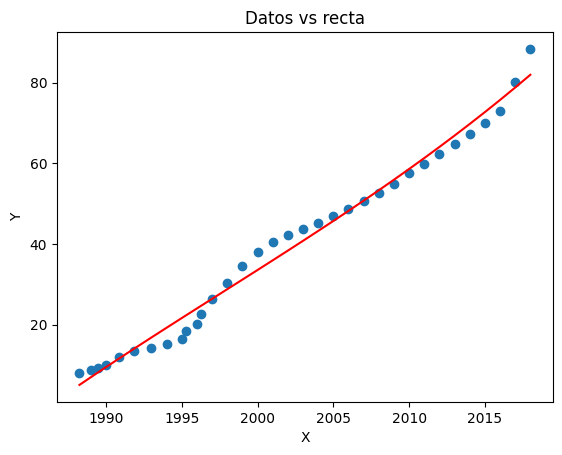

In [305]:
x = xsl_matrix
y = y_vec

y_recta_3 = inter_3 + var_3[0,0] * x**1 + var_3[0,1] * x**2 + var_3[0,2] * x**3

plt.scatter(x, y)
plt.plot(x, y_recta_3, color='red')

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Datos vs recta")

plt.show()

*GRADO 5*

In [306]:
#Creo arrays de X / Y, además de agregar variable libre de grado 5
x5sl_matrix = np.array([[sl[0], sl[0]**2,sl[0]**3,sl[0]**4,sl[0]**5] for sl in matriz_])
y_vec = np.array([[sl[1]] for sl in matriz_])
x5sl_matrix

array([[1.98825000e+03, 3.95313806e+06, 7.85982675e+09, 1.56273005e+13,
        3.10709803e+16],
       [1.98900000e+03, 3.95612100e+06, 7.86872467e+09, 1.56508934e+13,
        3.11296269e+16],
       [1.98950000e+03, 3.95811025e+06, 7.87466034e+09, 1.56666368e+13,
        3.11687738e+16],
       [1.99000000e+03, 3.96010000e+06, 7.88059900e+09, 1.56823920e+13,
        3.12079601e+16],
       [1.99084000e+03, 3.96344391e+06, 7.89058267e+09, 1.57088876e+13,
        3.12738818e+16],
       [1.99184000e+03, 3.96742659e+06, 7.90247897e+09, 1.57404737e+13,
        3.13525052e+16],
       [1.99300000e+03, 3.97204900e+06, 7.91629366e+09, 1.57771733e+13,
        3.14439063e+16],
       [1.99400000e+03, 3.97603600e+06, 7.92821578e+09, 1.58088623e+13,
        3.15228714e+16],
       [1.99500000e+03, 3.98002500e+06, 7.94014988e+09, 1.58405990e+13,
        3.16019950e+16],
       [1.99530000e+03, 3.98122209e+06, 7.94373244e+09, 1.58501293e+13,
        3.16257631e+16],
       [1.99600000e+03, 3.9840

In [307]:
lr = LinearRegression(fit_intercept= True) #no consideramos los interceptos
lr.fit(x5sl_matrix, y_vec) #Entrenamos la regresión
inter_5 = lr.intercept_  #Intercepto
inter_5

array([-534328.79079363])

In [308]:
lr.score(x5sl_matrix, y_vec)

0.9857546631343813

In [309]:
var_5 = lr.coef_ #variables libres ajustadas
var_5

array([[ 3.32926286e-10,  6.66831636e-07,  6.67827159e-04,
        -5.01138166e-07,  1.00311032e-10]])

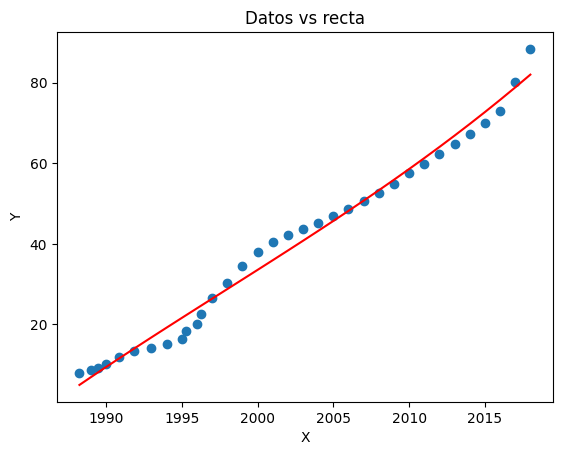

In [310]:
x = xsl_matrix
y = y_vec

y_recta_5 = inter_5 + var_5[0,0] * x**1 + var_5[0,1] * x**2 + var_5[0,2] * x**3 + var_5[0,3] * x**4 + var_5[0,4] * x**5

plt.scatter(x, y)
plt.plot(x, y_recta_5, color='red')

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Datos vs recta")

plt.show()

*GRADO 7*

In [311]:
x7sl_matrix = np.array([[sl[0], sl[0]**2,sl[0]**3,sl[0]**4,sl[0]**5,sl[0]**6,sl[0]**7] for sl in matriz_])
y7Sl_matrix = np.array([[sl[1]] for sl in matriz_])
x7sl_matrix

array([[1.98825000e+03, 3.95313806e+06, 7.85982675e+09, 1.56273005e+13,
        3.10709803e+16, 6.17768766e+19, 1.22827875e+23],
       [1.98900000e+03, 3.95612100e+06, 7.86872467e+09, 1.56508934e+13,
        3.11296269e+16, 6.19168279e+19, 1.23152571e+23],
       [1.98950000e+03, 3.95811025e+06, 7.87466034e+09, 1.56666368e+13,
        3.11687738e+16, 6.20102755e+19, 1.23369443e+23],
       [1.99000000e+03, 3.96010000e+06, 7.88059900e+09, 1.56823920e+13,
        3.12079601e+16, 6.21038406e+19, 1.23586643e+23],
       [1.99084000e+03, 3.96344391e+06, 7.89058267e+09, 1.57088876e+13,
        3.12738818e+16, 6.22612948e+19, 1.23952276e+23],
       [1.99184000e+03, 3.96742659e+06, 7.90247897e+09, 1.57404737e+13,
        3.13525052e+16, 6.24491739e+19, 1.24388762e+23],
       [1.99300000e+03, 3.97204900e+06, 7.91629366e+09, 1.57771733e+13,
        3.14439063e+16, 6.26677053e+19, 1.24896737e+23],
       [1.99400000e+03, 3.97603600e+06, 7.92821578e+09, 1.58088623e+13,
        3.15228714e+16, 6

In [312]:
lr = LinearRegression(fit_intercept= True) #no consideramos los interceptos
lr.fit(x7sl_matrix, y_vec) #Entrenamos la regresión
inter_7 = lr.intercept_  #Intercepto
inter_7

array([-156804.77949518])

In [313]:
lr.score(x7sl_matrix, y_vec)

0.9857730993924559

In [314]:
var_7 = lr.coef_
var_7

array([[ 1.91160388e-23, -1.65984995e-18,  9.20291789e-17,
         1.22888842e-13,  1.02560834e-10, -8.54813517e-14,
         1.83257513e-17]])

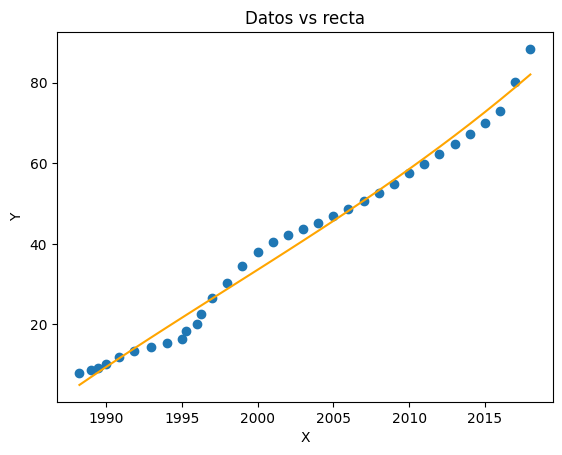

In [315]:
x = xsl_matrix
y = y_vec

y_recta_7 = inter_7 + var_7[0,0] * x**1 + var_7[0,1] * x**2 + var_7[0,2] * x**3 + var_7[0,3] * x**4 + var_7[0,4] * x**5 + var_7[0,5] * x**6 + var_7[0,6] * x**7

plt.scatter(x, y)
plt.plot(x, y_recta_7, color='orange')

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Datos vs recta")

plt.show()


***COMPARAMOS LAS REGRESIONES ... ***

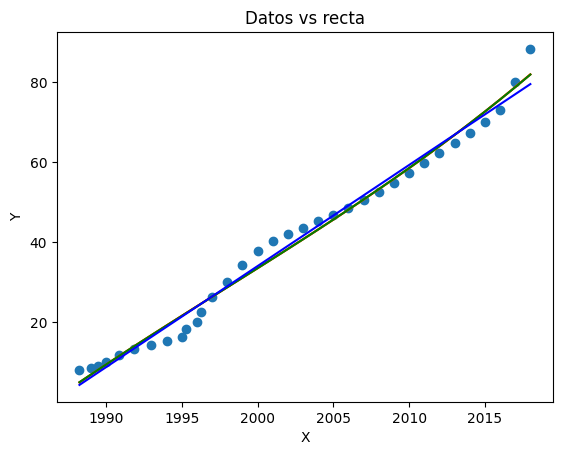

In [316]:
x = xsl_matrix
y = y_vec


plt.scatter(x, y)
plt.plot(x, y_recta_7, color='orange')
plt.plot(x, y_recta_5, color='red')
plt.plot(x, y_recta_3, color='green')
plt.plot(x, y_recta, color='blue')


plt.xlabel("X")
plt.ylabel("Y")
plt.title("Datos vs recta")

plt.show()
